In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


mortality = pd.read_excel("data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",sheet_name="20q5, 10q10",skiprows=14)

mortality.columns = mortality.columns.str.strip()

mortality = mortality[["Region", "Sex", "Year", "Median"]] #data analizi için only relevant variablesları seçtim

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()
# veriyi region + year bazında ortalama alarak özetliyoruz, ayrıca bu adımla sex ve region level kısmını datasetten çıkardık
hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)

hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)#gereksiz satırları silip index’i resetledim
hdi.head()

econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]

econ = econ.iloc[1:].reset_index(drop=True)

econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")


mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")

mapping = mapping[["Country", "UNICEF Region"]]
#mapping = mapping.rename(columns={"UNICEF Region": " UNICEF Region"})
econ = econ.merge(mapping, on="Country", how="left")#burada econ datasındaki ülkelere, mapping datasından hangi bölgeye ait olduklarını ekledik

hdi = hdi.merge(mapping, on="Country", how="left")#burada da HDI verisindeki ülkelere hangi bölgeye ait olduklarını ekledik

hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()#ülkeleri bölgelere göre gruplayıp ortalama HDI hesaplıyoruz

region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}
#burada kısaltılmış region kodlarını tam isimlere çevirmek için mapping oluşturdum(gpt söyledi)
hdi_region["Region"] = hdi_region["Region"].replace(region_map)
hdi_region
econ_region = econ.groupby("UNICEF Region")[["health_spending", "education_spending"]].mean().reset_index()
econ_region["UNICEF Region"] = econ_region["UNICEF Region"].replace(region_map)


econ_region = econ_region.rename(columns={"UNICEF Region": "Region"})

df = mortality.merge(hdi_region, on="Region", how="left") #burada mortality datasına hdi ekledim
df = df.merge(econ_region, on="Region", how="left")#burada da economic verileri ekledim

df.head()

,Region,Year,mort_median_5_24,HDI,health_spending,education_spending
0,East Asia and Pacific,1990,18.477822,0.735857,4.563424,4.522219
1,East Asia and Pacific,1991,18.001312,0.735857,4.563424,4.522219
2,East Asia and Pacific,1992,17.444175,0.735857,4.563424,4.522219
3,East Asia and Pacific,1993,16.978292,0.735857,4.563424,4.522219
4,East Asia and Pacific,1994,16.549464,0.735857,4.563424,4.522219


In [2]:
fix_map = {
    "Eastern Europe and Central Asia": "Europe and Central Asia",
    "Western Europe": "Europe and Central Asia",
    "Eastern and Southern Africa": "Sub-Saharan Africa",
    "West and Central Africa": "Sub-Saharan Africa",
    "North America": "Europe and Central Asia",  # approx (dataset'e göre kabul)
    "World": None  # bunu istemiyoruz
}

df["Region"] = df["Region"].replace(fix_map)#mortality datasetindeki region isimlerini diğer datasetlerle uyumlu hale getirdik


df = mortality.copy()
df["Region"] = df["Region"].replace(fix_map)

df = df.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")
df = df[df["Region"].notna()].reset_index(drop=True)# burada region değeri boş (NaN) olan satırları sildik, sonra index’i sıfırlayıp düzenledik
df.isnull().sum()

Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

In [3]:
hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()

econ_region = econ.groupby("Region")[["health_spending", "education_spending"]].mean().reset_index()

KeyError: 'Region'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) MORTALITY DATA
# -------------------------

mortality = pd.read_excel(
    "data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",
    sheet_name="20q5, 10q10",
    skiprows=14
)

mortality.columns = mortality.columns.str.strip()

mortality = mortality[["Region", "Sex", "Year", "Median"]]

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

mortality["mort_median_5_24"] = pd.to_numeric(
    mortality["mort_median_5_24"],
    errors="coerce"
)

mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()


# -------------------------
# 2) HDI DATA
# -------------------------

hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)

hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)

hdi["Country"] = hdi["Country"].astype(str).str.strip()
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")


# -------------------------
# 3) ECONOMIC DATA
# -------------------------

econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]
econ = econ.iloc[1:].reset_index(drop=True)

econ["Country"] = econ["Country"].astype(str).str.strip()
econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")


# -------------------------
# 4) REGION MAPPING
# -------------------------

mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")
mapping.columns = mapping.columns.str.strip()

mapping = mapping[["Country", "UNICEF Region"]]
mapping["Country"] = mapping["Country"].astype(str).str.strip()

region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}


# -------------------------
# 5) MERGE HDI + ECON WITH REGION
# -------------------------

hdi = hdi.merge(mapping, on="Country", how="left")
hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["Region"] = hdi["Region"].replace(region_map)

econ = econ.merge(mapping, on="Country", how="left")
econ = econ.rename(columns={"UNICEF Region": "Region"})
econ["Region"] = econ["Region"].replace(region_map)


# -------------------------
# 6) REGION-LEVEL AVERAGES
# -------------------------

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()

econ_region = econ.groupby("Region")[["health_spending", "education_spending"]].mean().reset_index()


# -------------------------
# 7) FINAL DATAFRAME
# -------------------------

df = mortality.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

df = df.dropna().reset_index(drop=True)

df.head()

,Region,Year,mort_median_5_24,HDI,health_spending,education_spending
0,East Asia and Pacific,1990,18.477822,0.735857,4.563424,4.522219
1,East Asia and Pacific,1991,18.001312,0.735857,4.563424,4.522219
2,East Asia and Pacific,1992,17.444175,0.735857,4.563424,4.522219
3,East Asia and Pacific,1993,16.978292,0.735857,4.563424,4.522219
4,East Asia and Pacific,1994,16.549464,0.735857,4.563424,4.522219


In [ ]:
df.isnull().sum()

Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df[["HDI", "health_spending", "education_spending"]]
y = df["mort_median_5_24"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 99.71177768317033
R2: 0.6401917908990957


* The model explains about 64% of the variation in youth mortality.
* This is pretty good, especially for a simple KNN model with only 3 features.
* However, 36% is still unexplained, meaning there are other important factors missing (inequality, healthcare quality, conflict, etc.).

In [ ]:
for k in range(1, 15):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    print(k, r2_score(y_test, y_pred))

1 0.7523983316922265
2 0.6527878933893807
3 0.6611660212768913
4 0.680923101452519
5 0.6401917908990957
6 0.702214668466725
7 0.7670808918615855
8 0.7850269766711434
9 0.7862399341838049
10 0.787287678255176
11 0.788118644041574
12 0.7777880452395781
13 0.7823901237012959
14 0.7865563558728876


* The model performs best around k ≈ 9–11
* R² increased from 0.64 → ~0.78
* This means tuning K significantly improved the model

In [ ]:
knn = KNeighborsRegressor(n_neighbors=10)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 58.94785944236975
R2: 0.787287678255176


The KNN model performance improves significantly as the number of neighbors increases, reaching its peak around k=10 (R² ≈ 0.78). This suggests that a moderate number of neighbors helps capture the general pattern while reducing noise. Smaller values of k tend to overfit, while larger values provide more stable and reliable predictions.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["HDI", "health_spending", "education_spending"]]
y = df["mort_median_5_24"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_linear))
print("Linear Regression R2:", r2_score(y_test, y_pred_linear))

Linear Regression MSE: 98.88599046410343
Linear Regression R2: 0.6431716296633285


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=10)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))
print("KNN R2:", r2_score(y_test, y_pred_knn))

KNN MSE: 58.94785944236975
KNN R2: 0.787287678255176


In [ ]:
for k in range(1, 15):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    
    print(k, r2_score(y_test, y_pred))

1 0.7523983316922265
2 0.6527878933893807
3 0.6611660212768913
4 0.680923101452519
5 0.6401917908990957
6 0.702214668466725
7 0.7670808918615855
8 0.7850269766711434
9 0.7862399341838049
10 0.787287678255176
11 0.788118644041574
12 0.7777880452395781
13 0.7823901237012959
14 0.7865563558728876


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regression"],
    "MSE": [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_knn)
    ],
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_knn)
    ]
})

comparison

,Model,MSE,R2
0,Linear Regression,98.885990,0.643172
1,KNN Regression,58.947859,0.787288


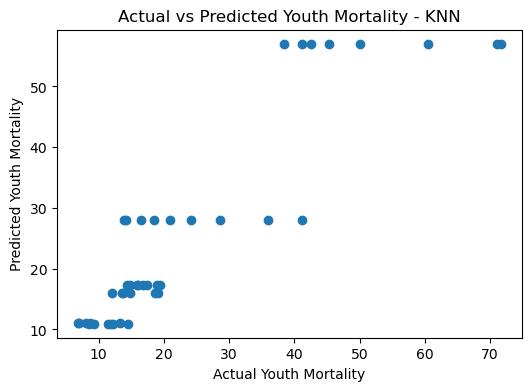

In [ ]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test, y_pred_knn)

plt.xlabel("Actual Youth Mortality")
plt.ylabel("Predicted Youth Mortality")
plt.title("Actual vs Predicted Youth Mortality - KNN")

plt.show()

## Machine Learning Model

In this section, Linear Regression and KNN Regression models were used to predict youth mortality rates based on HDI, health spending, and education spending.

Linear Regression was used as a baseline model because it captures the global linear relationship between predictors and the target variable.

KNN Regression was also applied because it can capture more local patterns in the data. Since KNN is distance-based, feature scaling was applied using StandardScaler.

Model performance was evaluated using Mean Squared Error (MSE) and R² score. A lower MSE and higher R² indicate better predictive performance.

In [ ]:
baseline_pred = np.mean(y_train)

baseline_preds = [baseline_pred] * len(y_test)

print("Baseline MSE:", mean_squared_error(y_test, baseline_preds))
print("Baseline R2:", r2_score(y_test, baseline_preds))

Baseline MSE: 277.3916395400639
Baseline R2: -0.0009628888535988533


as you see from here, the KNN model performs substantially better than a simple mean baseline, indicating that HDI, health spending, and education spending contain meaningful predictive information about youth mortality.

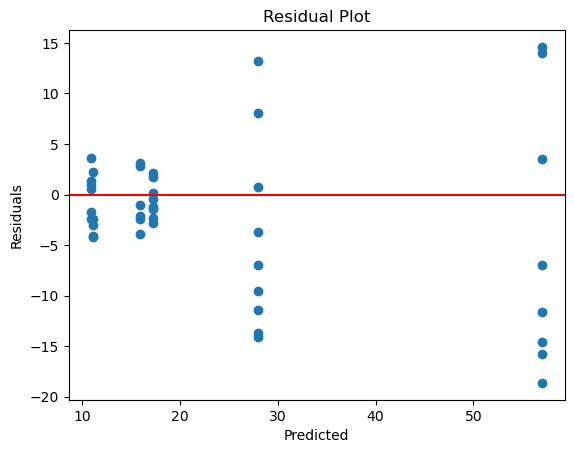

In [ ]:
residuals = y_test - y_pred_knn

plt.scatter(y_pred_knn, residuals)
plt.axhline(0, color='red')

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

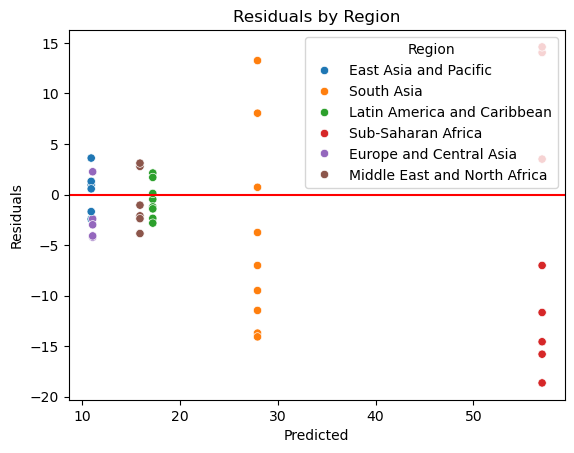

In [ ]:
sns.scatterplot(x=y_pred_knn, y=residuals, hue=df.loc[y_test.index, "Region"])
plt.axhline(0, color='red')
plt.xlabel("Predicted"); plt.ylabel("Residuals"); plt.title("Residuals by Region")
plt.show()

so residual analysis reveals systematic differences across regions. The model tends to overestimate mortality in some regions (e.g., Sub-Saharan Africa) and underestimate in others. This indicates that while the model captures the overall relationship, it fails to fully account for region-specific factors affecting youth mortality.

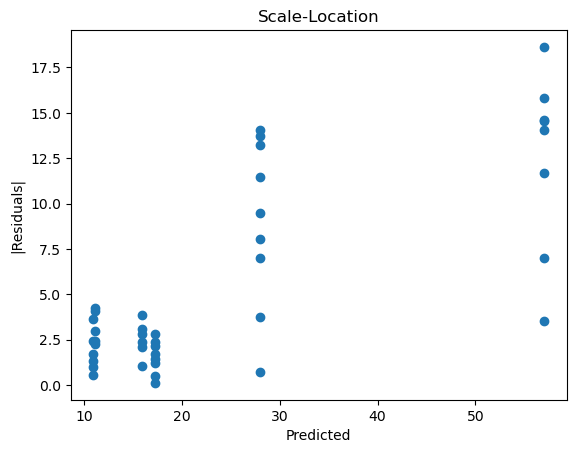

In [ ]:
plt.scatter(y_pred_knn, np.abs(residuals))
plt.xlabel("Predicted"); plt.ylabel("|Residuals|"); plt.title("Scale-Location")
plt.show()

* Model iyi ama mükemmel değil.
* Hatalar region/HDI seviyesine bağlı değişiyor olabilir.
* so “Development alone does not fully explain mortality differences.”

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coef_df

,Feature,Coefficient
0,HDI,-139.899184
1,health_spending,0.285788
2,education_spending,0.379815


Due to strong multicollinearity among HDI, health spending, and education spending, coefficient estimates are unstable and should be interpreted with caution. The model struggles to isolate the individual effect of each variable.

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[["HDI"]]
y = df["mort_median_5_24"]

model = LinearRegression()
model.fit(X, y)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,HDI,-135.00057


* coefficient NEGATİF 
* bu = “HDI ↑ → mortality ↓”

In [ ]:
X = df[["health_spending", "education_spending"]]
y = df["mort_median_5_24"]

model = LinearRegression()
model.fit(X, y)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,health_spending,-13.698116
1,education_spending,25.442508


In [ ]:
df[["health_spending", "education_spending"]].corr()

,health_spending,education_spending
health_spending,1.000000,0.973844
education_spending,0.973844,1.000000


Health and education spending are highly correlated, indicating that they capture similar underlying development patterns. This leads to multicollinearity, making it difficult to isolate their individual effects.

in conclusion the analysis shows that socio-economic development, measured by HDI, has a strong impact on youth mortality. However, even after accounting for development, significant regional differences remain. This suggests that additional factors beyond economic indicators influence mortality outcomes.

## Additional Exploratory Analysis

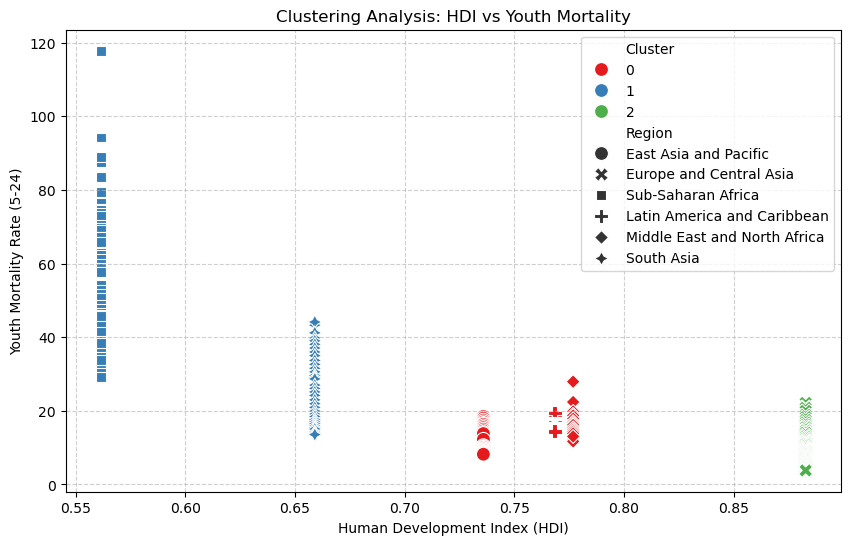

In [5]:
# --- ADIM 1: GEREKLİ KÜTÜPHANELER ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- ADIM 2: ÖZELLİK SEÇİMİ VE ÖLÇEKLENDİRME ---
features = ["HDI", "health_spending", "education_spending", "mort_median_5_24"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- ADIM 3: K-MEANS CLUSTERING ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# --- ADIM 4: GÖRSELLEŞTİRME ---
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    hue="Cluster",
    style="Region",
    palette="Set1",
    s=100
)

plt.title("Clustering Analysis: HDI vs Youth Mortality")
plt.xlabel("Human Development Index (HDI)")
plt.ylabel("Youth Mortality Rate (5-24)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

The clustering results clearly separate countries based on development levels. Low-HDI regions form a distinct cluster with high and highly variable mortality rates, while high-HDI regions are grouped together with lower and more stable outcomes. This suggests that development level is a key factor shaping both the level and variability of youth mortality.
It is important to note that clustering results are strongly influenced by HDI, which dominates the grouping structure due to its strong relationship with mortality.

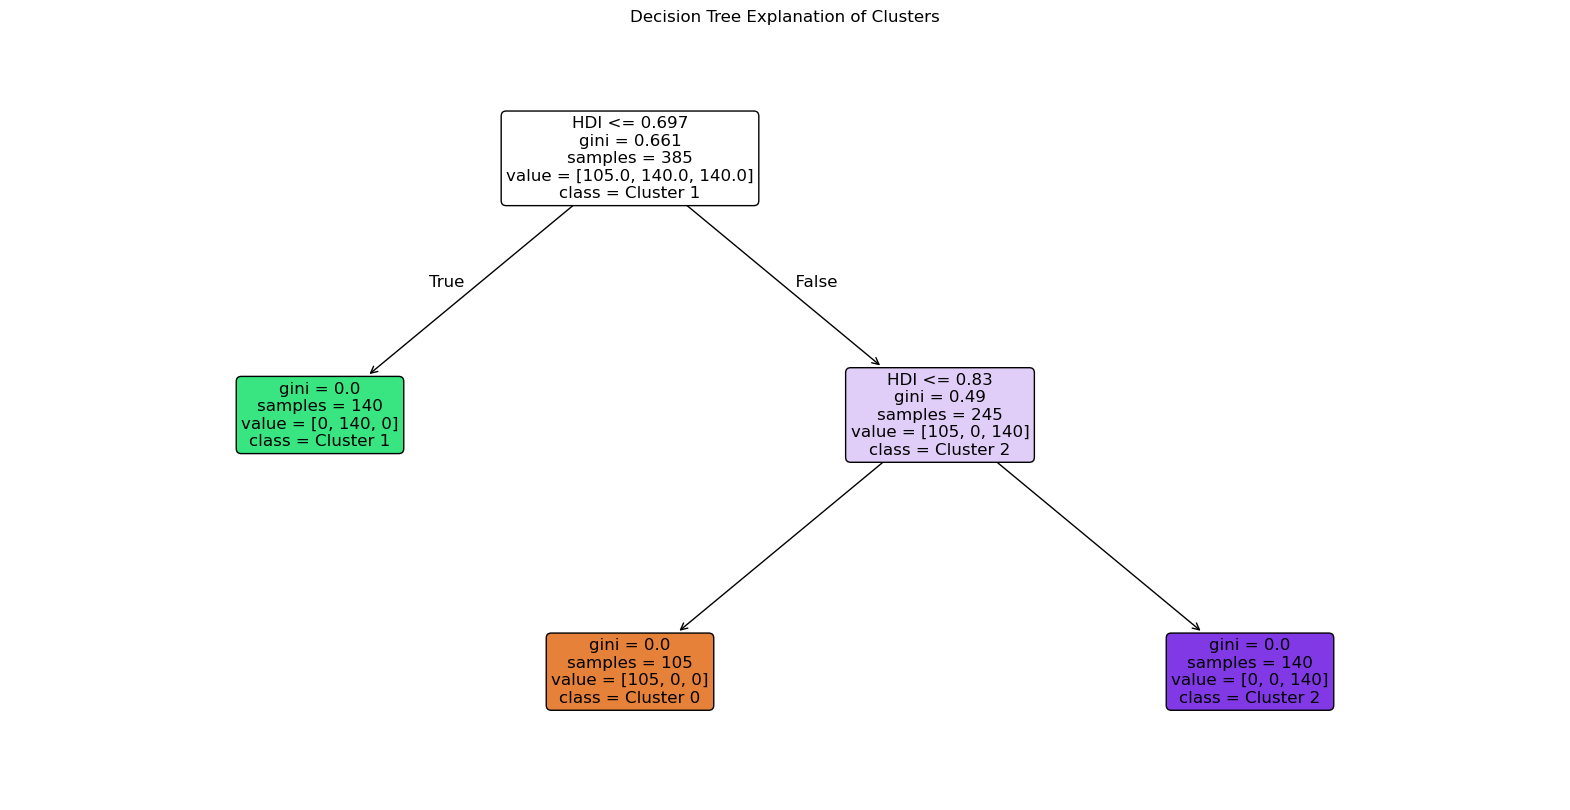

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# KMeans'te kullandığın feature'lar
features = ["HDI", "health_spending", "education_spending", "mort_median_5_24"]

X_tree = df[features]
y_tree = df["Cluster"]

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_tree, y_tree)

plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=features,
    class_names=["Cluster 0", "Cluster 1", "Cluster 2"],
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title("Decision Tree Explanation of Clusters")
plt.show()

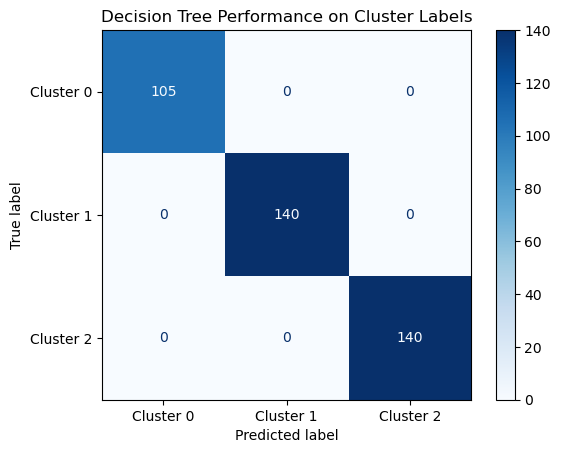

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Feature'lar (tree'de kullandığınla aynı olmalı)
features = ["HDI", "health_spending", "education_spending", "mort_median_5_24"]

X_tree = df[features]
y_true = df["Cluster"]

# Tahmin
y_pred = clf.predict(X_tree)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cluster 0", "Cluster 1", "Cluster 2"]
)

disp.plot(cmap="Blues")
plt.title("Decision Tree Performance on Cluster Labels")
plt.show()

### Confusion Matrix for Cluster Interpretation

A confusion matrix was used to evaluate how well the decision tree can reproduce the clusters generated by K-Means.

A strong diagonal pattern indicates that the clusters are well-separated and can be effectively explained by the selected features.

This analysis supports the idea that the clustering structure is meaningful and not random.

It is important to note that this evaluation does not measure predictive performance on unseen data, but rather the consistency between clustering results and the decision tree interpretation.

In [9]:
# ===== Additional Classification Analysis: Mortality Increase Prediction =====

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# 1) Create yearly change variable
df_change = df.sort_values(["Region", "Year"]).copy()

df_change["mortality_change"] = df_change.groupby("Region")["mort_median_5_24"].diff()

df_change["increase_flag"] = (df_change["mortality_change"] > 0).astype(int)

df_change = df_change.dropna().reset_index(drop=True)


# 2) Feature selection
num_cols = ["HDI", "health_spending", "education_spending", "Year"]
cat_cols = ["Region"]

X = df_change[num_cols + cat_cols]
y = df_change["increase_flag"]


# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 4) Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)


# 5) Classification models
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5)
}


# 6) Train and compare models
rows = []
best_model_name = None
best_f1 = -1
best_pipe = None

for name, clf in clf_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    rows.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipe = pipe


classification_results = pd.DataFrame(rows).sort_values("F1 Score", ascending=False)

classification_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.776316,0.514286
1,Decision Tree,0.763158,0.500000
2,KNN Classifier,0.684211,0.400000


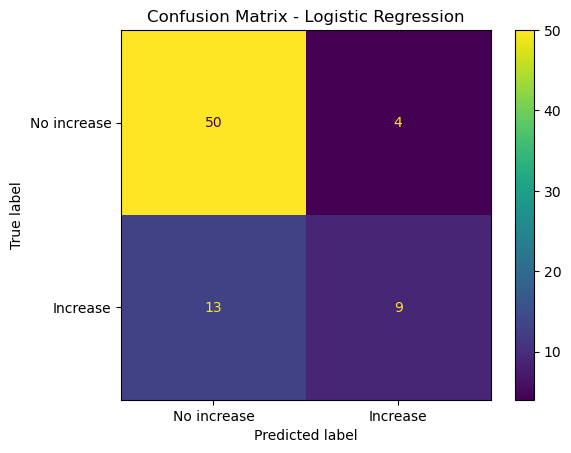

              precision    recall  f1-score   support

           0       0.79      0.93      0.85        54
           1       0.69      0.41      0.51        22

    accuracy                           0.78        76
   macro avg       0.74      0.67      0.68        76
weighted avg       0.76      0.78      0.76        76



In [10]:
# 7) Confusion matrix for the best classifier

best_pred = best_pipe.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["No increase", "Increase"],
    values_format="d"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print(classification_report(y_test, best_pred))

## Additional Classification Analysis

In addition to predicting mortality levels, a classification task was created to examine whether youth mortality increased compared to the previous year.

The target variable `increase_flag` was defined as 1 if mortality increased from the previous year and 0 otherwise. Logistic Regression, Decision Tree, and KNN Classifier models were compared using accuracy and F1 score.

This analysis provides an additional perspective by focusing not on the level of mortality, but on whether mortality trends worsen over time.

Linear R2: 0.6667458118877472
KNN R2: 0.7621608635649075
Baseline R2: -0.0013949889792421732


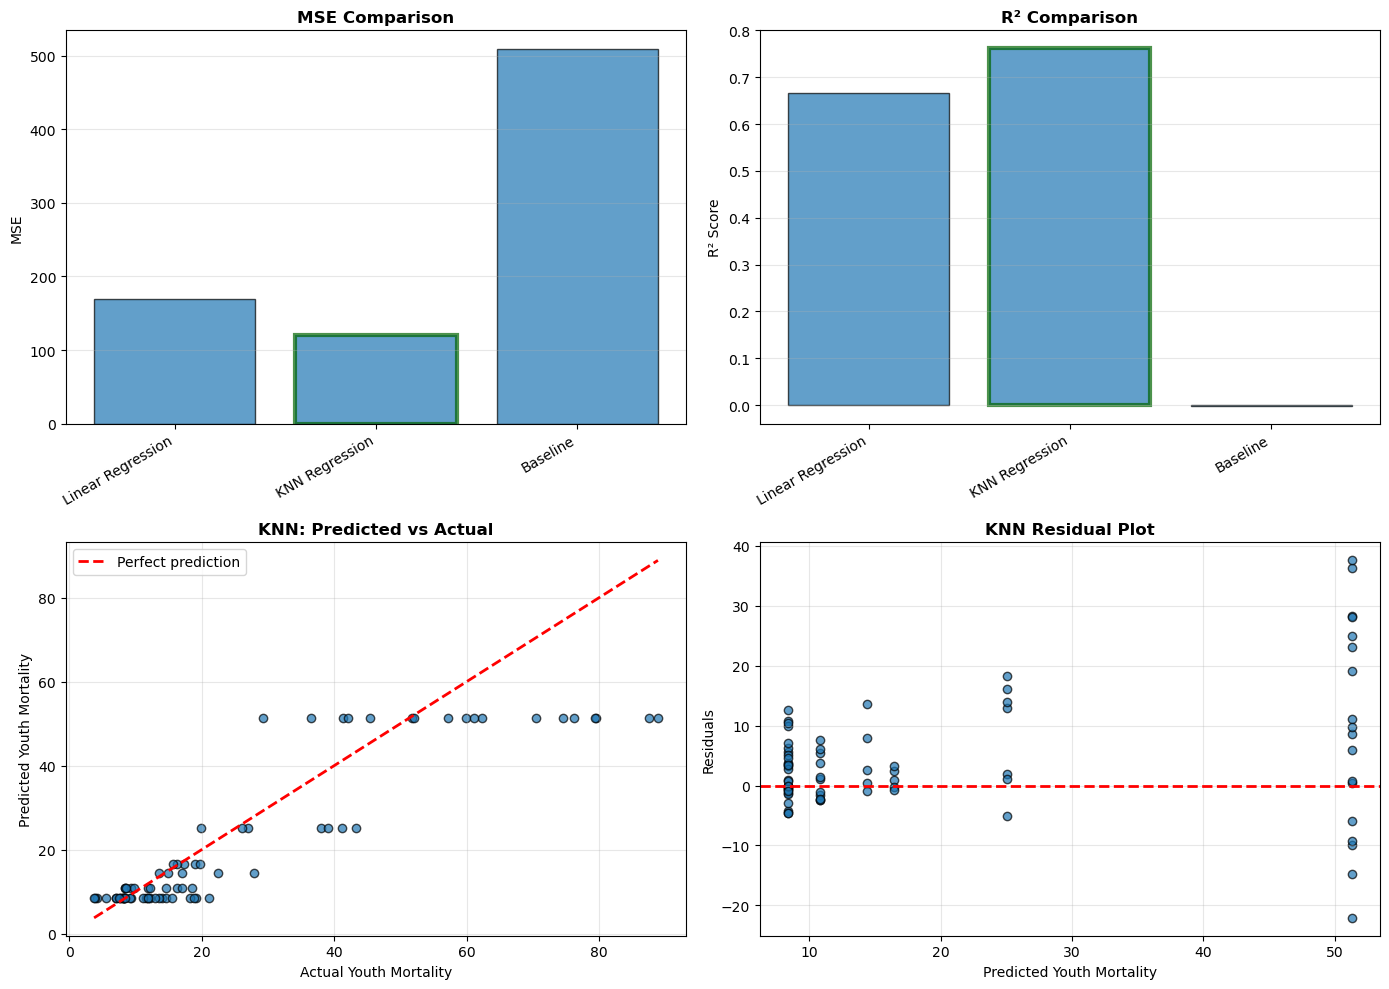

Saved: model_results_dashboard.png


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[["HDI", "health_spending", "education_spending"]]
y = df["mort_median_5_24"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# KNN Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Baseline
baseline_pred = np.mean(y_train)
baseline_preds = [baseline_pred] * len(y_test)

print("Linear R2:", r2_score(y_test, y_pred_linear))
print("KNN R2:", r2_score(y_test, y_pred_knn))
print("Baseline R2:", r2_score(y_test, baseline_preds))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -------------------------
# 1) MSE Comparison
# -------------------------
ax = axes[0, 0]

models = ["Linear Regression", "KNN Regression", "Baseline"]
mse_vals = [
    mean_squared_error(y_test, y_pred_linear),
    mean_squared_error(y_test, y_pred_knn),
    mean_squared_error(y_test, baseline_preds)
]

bars = ax.bar(range(len(models)), mse_vals, alpha=0.7, edgecolor="black")

best_idx = mse_vals.index(min(mse_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_title("MSE Comparison", fontweight="bold")
ax.set_ylabel("MSE")
ax.grid(alpha=0.3, axis="y")


# -------------------------
# 2) R2 Comparison
# -------------------------
ax = axes[0, 1]

r2_vals = [
    r2_score(y_test, y_pred_linear),
    r2_score(y_test, y_pred_knn),
    r2_score(y_test, baseline_preds)
]

bars = ax.bar(range(len(models)), r2_vals, alpha=0.7, edgecolor="black")

best_idx = r2_vals.index(max(r2_vals))
bars[best_idx].set_edgecolor("darkgreen")
bars[best_idx].set_linewidth(3)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_title("R² Comparison", fontweight="bold")
ax.set_ylabel("R² Score")
ax.grid(alpha=0.3, axis="y")


# -------------------------
# 3) Predicted vs Actual - KNN
# -------------------------
ax = axes[1, 0]

ax.scatter(y_test, y_pred_knn, alpha=0.7, edgecolor="black")

min_val = min(y_test.min(), y_pred_knn.min())
max_val = max(y_test.max(), y_pred_knn.max())

ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual Youth Mortality")
ax.set_ylabel("Predicted Youth Mortality")
ax.set_title("KNN: Predicted vs Actual", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)


# -------------------------
# 4) Residual Plot - KNN
# -------------------------
ax = axes[1, 1]

residuals = y_test - y_pred_knn

ax.scatter(y_pred_knn, residuals, alpha=0.7, edgecolor="black")
ax.axhline(0, color="red", linestyle="--", linewidth=2)

ax.set_xlabel("Predicted Youth Mortality")
ax.set_ylabel("Residuals")
ax.set_title("KNN Residual Plot", fontweight="bold")
ax.grid(alpha=0.3)


plt.tight_layout()
plt.savefig("model_results_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: model_results_dashboard.png")